# <font color="#418FDE" size="6.5" uppercase>**Introductory NLP Libraries and Hugging Face Workflows**</font>

>Last update: 20260423.
    
By the end of this Lecture, you will be able to:
- Use spaCy and NLTK to preprocess and analyze simple text data relevant to civil engineering workflows. 
- Apply beginner-friendly Hugging Face workflows for introductory text, image, audio, and video generation tasks. 
- Describe the basic input-output patterns of single-modal and multi-modal AI tasks using simple Python examples. 


## **1. spaCy and NLTK Basics**

### **1.1. Text Cleaning Basics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_01_01.jpg?v=1776979031" width="250">



>* Cleaning standardizes messy civil engineering text.
>* Preserve technical meaning while removing noise.

>* Tokenize and normalize text for analysis.
>* Keep engineering details, remove only noise.

>* Clean text for the engineering task.
>* Preserve meaning; spaCy and NLTK help.



Before and after text:
- Bridge Deck crack near Pier 2, width 5 mm.
  bridge deck crack near pier 2 width 5 mm
- Drain blocked at culvert inlet!!! Remove debris soon.
  drain blocked at culvert inlet remove debris soon
- Concrete spalling seen on wall panel B-3.
  concrete spalling seen on wall panel b-3

Token summary table:
 original_count  cleaned_count  avg_token_length
             11              9              3.56
             10              8              5.25
             10              9              3.78


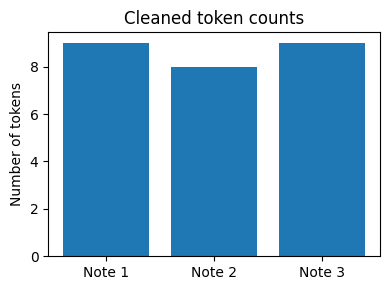

In [1]:
#@title Python Code - Text Cleaning Basics

# This lesson cleans short inspection notes.
# We compare spaCy and NLTK basics.
# Small examples fit beginner workflows.

# Dataset uses short civil inspection sentences.
import pandas as pd
import matplotlib.pyplot as plt

import spacy

# NLTK tools here need no downloads.
from nltk.tokenize import wordpunct_tokenize
from nltk.stem import PorterStemmer

# Build a tiny manual dataset.
texts = [
    "Bridge Deck crack near Pier 2, width 5 mm.",

    "Drain blocked at culvert inlet!!! Remove debris soon.",
    "Concrete spalling seen on wall panel B-3."]

# Create a lightweight spaCy pipeline.
nlp = spacy.blank("en")
stemmer = PorterStemmer()

df = pd.DataFrame({"original": texts})

# Clean one sentence with simple rules.
def clean_text(text):
    doc = nlp(text.lower())

    kept = []
    for token in doc:

        if token.is_punct or token.is_space:
            continue
        kept.append(token.text)

    return " ".join(kept)

# Apply cleaning to each sentence.
df["cleaned"] = df["original"].apply(clean_text)
df["spacy_tokens"] = df["cleaned"].apply(wordpunct_tokenize)

df["stems"] = df["spacy_tokens"].apply(
    lambda items: [stemmer.stem(word) for word in items])

# Count tokens before and after cleaning.
df["original_count"] = df["original"].apply(
    lambda text: len(wordpunct_tokenize(text)))

df["cleaned_count"] = df["spacy_tokens"].apply(len)

df["avg_token_length"] = df["spacy_tokens"].apply(
    lambda items: round(sum(len(word) for word in items) / len(items), 2))

# Show before and after examples.
print("Before and after text:")
for i in range(len(df)):

    print("-", df.loc[i, "original"])
    print(" ", df.loc[i, "cleaned"])

# Show a compact summary table.
summary = df[["original_count", "cleaned_count", "avg_token_length"]]
print("\nToken summary table:")

print(summary.to_string(index=False))

# Plot cleaned token counts.
plt.figure(figsize=(4, 3))
plt.bar(["Note 1", "Note 2", "Note 3"], df["cleaned_count"])

plt.title("Cleaned token counts")
plt.ylabel("Number of tokens")

# Finish the compact plot.
plt.tight_layout()
plt.show()

### **1.2. Entity and Keyword Rules**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_01_02.jpg?v=1776979060" width="250">



>* Entities identify important engineering text items.
>* Keyword rules flag relevant document topics.

>* spaCy matches technical terms with custom rules.
>* NLTK finds frequent words to improve extraction.

>* Rules quickly find key inspection details.
>* They organize text for consistent decisions.



Entity matches table
 Note Matched Text Entity Label
    1       Bridge        ASSET
    1       Pier 3     LOCATION
    1       severe     SEVERITY
    1     spalling       DEFECT
    2 Road segment        ASSET
    2   River Road     LOCATION
    2     moderate     SEVERITY
    2     cracking       DEFECT
    3      Culvert        ASSET
    3   North Gate     LOCATION
    3        minor     SEVERITY
    3    corrosion       DEFECT

Top keyword frequencies
   Keyword  Frequency
      near          2
      road          2
    bridge          1
inspection          1
      pier          1
     found          1
    severe          1
  spalling          1


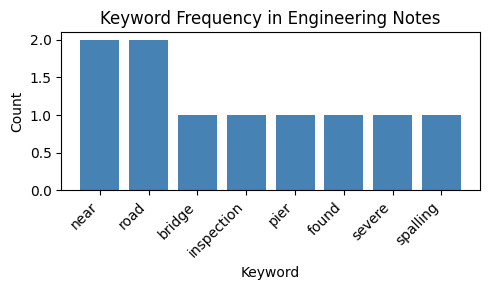

In [2]:
#@title Python Code - Entity and Keyword Rules

# Simple rule based NLP lesson.
# Civil engineering notes become structured.
# spaCy and NLTK work together.

# pip install spacy nltk

# Import small beginner friendly libraries.
import random, nltk, spacy, pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from spacy.pipeline import EntityRuler

# Set a deterministic random seed.
random.seed(7)
nltk.download("punkt", quiet=True)

nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Create tiny civil engineering notes.
notes = [
    "Bridge inspection at Pier 3 found severe spalling near the deck.",

    "Road segment on River Road shows moderate cracking and drainage blockage.",
    "Culvert near North Gate has minor corrosion and sediment buildup.",
    "Tunnel report says urgent settlement monitoring is needed downtown."]

# Build a blank English spaCy pipeline.
nlp = spacy.blank("en")
ruler = nlp.add_pipe("entity_ruler")

patterns = [
    {"label": "ASSET", "pattern": "Bridge"},
    {"label": "ASSET", "pattern": "Road segment"},

    {"label": "ASSET", "pattern": "Culvert"},
    {"label": "ASSET", "pattern": "Tunnel"},
    {"label": "DEFECT", "pattern": "spalling"},

    {"label": "DEFECT", "pattern": "cracking"},
    {"label": "DEFECT", "pattern": "corrosion"},
    {"label": "DEFECT", "pattern": "settlement"},

    {"label": "SEVERITY", "pattern": "severe"},
    {"label": "SEVERITY", "pattern": "moderate"},
    {"label": "SEVERITY", "pattern": "minor"},

    {"label": "SEVERITY", "pattern": "urgent"},
    {"label": "LOCATION", "pattern": "Pier 3"},
    {"label": "LOCATION", "pattern": "River Road"},

    {"label": "LOCATION", "pattern": "North Gate"},
    {"label": "LOCATION", "pattern": "downtown"}]

# Add simple entity rules.
ruler.add_patterns(patterns)
entity_rows = []

for note_id, text in enumerate(notes, start=1):
    doc = nlp(text)
    for ent in doc.ents:

        entity_rows.append([note_id, ent.text, ent.label_])

# Make a compact entity table.
entity_df = pd.DataFrame(
    entity_rows,

    columns=["Note", "Matched Text", "Entity Label"])
entity_df = entity_df.head(12)

# Prepare simple NLTK keyword tokens.
stop_words = set(stopwords.words("english"))
keywords = []

for text in notes:
    tokens = word_tokenize(text.lower())
    for token in tokens:

        if token.isalpha() and token not in stop_words:
            keywords.append(token)

# Count the most common keywords.
keyword_counts = Counter(keywords)
keyword_df = pd.DataFrame(

    keyword_counts.most_common(8),
    columns=["Keyword", "Frequency"])

# Print short labeled results.
print("Entity matches table")
print(entity_df.to_string(index=False))

print("\nTop keyword frequencies")
print(keyword_df.to_string(index=False))

# Plot a compact keyword chart.
plt.figure(figsize=(5, 3))
plt.bar(keyword_df["Keyword"], keyword_df["Frequency"], color="steelblue")

plt.title("Keyword Frequency in Engineering Notes")
plt.xlabel("Keyword")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **1.3. Civil Text Workflow**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_01_03.jpg?v=1776979099" width="250">



>* Clean and standardize civil project text.
>* Tokenize terms to compare recurring issues.

>* spaCy and NLTK reveal engineering text patterns.
>* Extracted categories highlight recurring issues and priorities.

>* Validate context with domain-aware human review.
>* Turn cleaned documents into practical engineering insights.



Civil text workflow summary
                        assets               defects  severity
note_id                                                       
1                 bridge, deck   cracking, corrosion      high
2                      culvert     blocked, flooding  moderate
3                     pavement     potholes, rutting       low
4                         wall  settlement, cracking      high
5                 tunnel, wall               leakage       low
6        road, shoulder, ditch               erosion  moderate

Defect category counts: {'cracking': 2, 'corrosion': 1, 'blocked': 1, 'flooding': 1, 'potholes': 1, 'rutting': 1, 'settlement': 1, 'leakage': 1, 'erosion': 1}


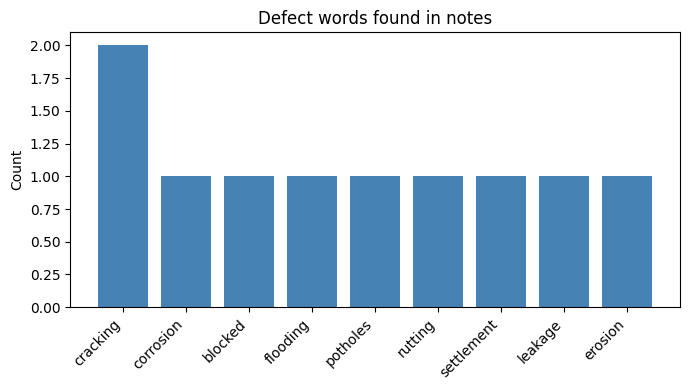

In [3]:
#@title Python Code - Civil Text Workflow

# Civil text workflow with simple tools.
# This example uses spaCy and NLTK.
# Inspection notes become structured project data.

# !pip install spacy nltk

# Import small libraries for analysis.
import random
import pandas as pd

import matplotlib.pyplot as plt
import spacy

# Import NLTK text helpers.
import nltk
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords

# Set seeds for repeatable results.
random.seed(7)
nltk.download("punkt", quiet=True)

nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

# Build a tiny spaCy pipeline.
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")

# Create small inspection note data.
notes = [
    "Bridge deck has cracking near joint and severe corrosion on railing.",

    "Culvert inlet blocked by debris after heavy rainfall, moderate flooding observed.",
    "Pavement section shows potholes and rutting, minor drainage issue nearby.",
    "Retaining wall inspection found settlement and cracking, high risk area.",

    "Tunnel lighting operational, only minor water leakage at side wall.",
    "Road shoulder erosion noted near ditch, moderate safety concern for traffic."]

# Store notes in a table.
df = pd.DataFrame({"note": notes})

# Define simple civil categories.
defect_words = [
    "cracking", "corrosion", "blocked", "flooding",

    "potholes", "rutting", "settlement", "leakage", "erosion"]
asset_words = [
    "bridge", "culvert", "pavement", "wall",

    "tunnel", "road", "deck", "shoulder", "ditch"]

# Define simple severity keywords.
severity_map = {
    "high": ["severe", "high", "risk"],

    "moderate": ["moderate"],
    "low": ["minor", "only"]}

# Clean and tokenize each note.
stop_words = set(stopwords.words("english"))
clean_tokens = []

for note in df["note"]:
    tokens = word_tokenize(note.lower())
    words = []

    for token in tokens:
        if token.isalpha() and token not in stop_words:
            words.append(token)

    clean_tokens.append(words)

df["tokens"] = clean_tokens

# Extract defects and assets.
defect_hits = []
asset_hits = []

for note in df["note"]:
    doc = nlp(note.lower())
    found_defects = []

    found_assets = []

    for token in doc:
        if token.text in defect_words:
            found_defects.append(token.text)

        if token.text in asset_words:
            found_assets.append(token.text)

    defect_hits.append(", ".join(found_defects))
    asset_hits.append(", ".join(found_assets))

df["defects"] = defect_hits
df["assets"] = asset_hits

# Group notes by simple severity.
severity_labels = []

for note in df["note"]:
    text = note.lower()
    label = "low"

    for word in severity_map["high"]:
        if word in text:
            label = "high"

    if label == "low":
        for word in severity_map["moderate"]:
            if word in text:

                label = "moderate"

    severity_labels.append(label)

df["severity"] = severity_labels

# Count extracted defect categories.
defect_counts = {}

for item in df["defects"]:
    parts = item.split(", ")
    for part in parts:

        if part != "":
            if part not in defect_counts:
                defect_counts[part] = 0

            defect_counts[part] = defect_counts[part] + 1

# Build a compact summary table.
summary = df[["assets", "defects", "severity"]].copy()
summary.index = summary.index + 1

summary.index.name = "note_id"

# Print short teaching outputs.
print("Civil text workflow summary")
print(summary.to_string())

print("\nDefect category counts:", defect_counts)

# Prepare values for one chart.
labels = list(defect_counts.keys())
values = list(defect_counts.values())

# Draw a compact bar chart.
plt.figure(figsize=(7, 4))
plt.bar(labels, values, color="steelblue")

plt.title("Defect words found in notes")
plt.ylabel("Count")

# Rotate labels for readability.
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## **2. Hugging Face Workflows**

### **2.1. Text Generation Basics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_02_01.jpg?v=1776979139" width="250">



>* Prompted text becomes generated written output.
>* Useful for simple civil engineering drafting.

>* Text generation includes many related tasks.
>* Hugging Face simplifies exploring input-output patterns.

>* Review generated text carefully for accuracy.
>* Use models as drafting aids, not authorities.



Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=24) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=24) and `max_length`(=50) see

Model: sshleifer/tiny-gpt2
Prompt and output table:
                                       Prompt                                          Generated_Text  Prompt_Tokens  Output_Tokens
        Maintenance note: sidewalk crack near Maintenance note: sidewalk crack near Daniel circumc...              5             23
        Inspection summary: bridge deck shows Inspection summary: bridge deck shows workshops brut...              5             25
Repair recommendation: drainage channel needs Repair recommendation: drainage channel needs equate...              5             22

Token-length summary:
      Prompt_Tokens  Output_Tokens
min             5.0           22.0
mean            5.0           23.3
max             5.0           25.0


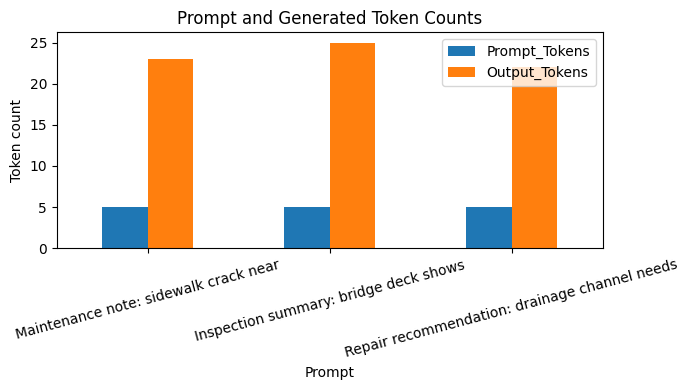

In [4]:
#@title Python Code - Text Generation Basics

# Simple Hugging Face text generation example.
# Civil engineering prompts stay short.
# Outputs are cleaned and summarized.

# pip install transformers accelerate

# Import small teaching libraries.
import random
import numpy as np

import pandas as pd

# Import plotting and pipeline tools.
import matplotlib.pyplot as plt
from transformers import pipeline

# Set deterministic seeds carefully.
random.seed(7)
np.random.seed(7)

# Choose a lightweight public model.
model_name = "sshleifer/tiny-gpt2"
text_pipe = pipeline("text-generation", model=model_name)

# Create short civil engineering prompts.
prompts = []
prompts.append("Maintenance note: sidewalk crack near")

prompts.append("Inspection summary: bridge deck shows")
prompts.append("Repair recommendation: drainage channel needs")

# Clean generated text gently.
def clean_text(text):
    text = text.replace("\n", " ")

    text = " ".join(text.split())
    return text.strip()

# Generate short outputs safely.
outputs = []
for prompt in prompts:

    result = text_pipe(
        prompt,
        max_new_tokens=24,

        do_sample=True,
        temperature=0.8,
        pad_token_id=50256)

    generated = result[0]["generated_text"]
    generated = clean_text(generated)
    outputs.append(generated)

# Build a compact results table.
df = pd.DataFrame()
df["Prompt"] = prompts

df["Generated_Text"] = outputs

df["Prompt_Tokens"] = df["Prompt"].str.split().str.len()
df["Output_Tokens"] = df["Generated_Text"].str.split().str.len()

# Summarize token lengths simply.
summary = df[["Prompt_Tokens", "Output_Tokens"]].agg(["min", "mean", "max"])
summary = summary.round(1)

# Print only compact visible results.
print("Model:", model_name)
print("Prompt and output table:")

print(df.to_string(index=False, max_colwidth=55))
print("\nToken-length summary:")
print(summary.to_string())

# Plot prompt and output lengths.
ax = df.plot(
    x="Prompt",

    y=["Prompt_Tokens", "Output_Tokens"],
    kind="bar",
    figsize=(7, 4),

    rot=15,
    title="Prompt and Generated Token Counts")

# Finish the compact plot.
ax.set_ylabel("Token count")
plt.tight_layout()

plt.show()

### **2.2. Vision and Speech**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_02_02.jpg?v=1776979170" width="250">



>* Vision and speech transform inputs into outputs.
>* Useful for engineering documentation and communication.

>* Vision tasks classify, caption, or answer questions.
>* Outputs help beginners, but need careful review.

>* Speech tools convert audio and text.
>* They streamline records, training, and communication.



Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'eos_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Image captions:
     image                                         caption  caption_words
bridge.jpg           a city street with cars and buildings              7
  road.jpg construction workers working on a building site              7

Audio summary:
                  file  sample_rate  seconds
inspection_summary.wav        16000      6.9

Saved audio file ./inspection_summary.wav


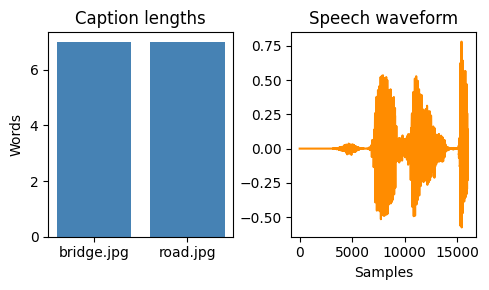

In [5]:
#@title Python Code - Vision and Speech

# Simple vision and speech workflow example.
# This script fits beginner civil engineering lessons.
# It uses Hugging Face pipelines carefully.

# !pip install -q transformers pillow scipy

# Download two infrastructure style images.
!wget -q -O bridge.jpg "https://images.unsplash.com/photo-1519501025264-65ba15a82390?fm=jpg&w=640"

# Download a second outdoor engineering image.
!wget -q -O road.jpg "https://images.unsplash.com/photo-1504307651254-35680f356dfd?fm=jpg&w=640"

# Import small teaching libraries.
import os
import numpy as np

import pandas as pd

# Import plotting and image tools.
import matplotlib.pyplot as plt
from scipy.io.wavfile import write

# Import Hugging Face pipelines.
from transformers import pipeline

# Set a deterministic random seed.
np.random.seed(7)

# Load image captioning pipeline with version safe fallback.
try:
    captioner = pipeline(

        task="image-to-text",
        model="Salesforce/blip-image-captioning-base")
    caption_mode = "image-to-text"

except KeyError:
    captioner = pipeline(
        task="image-text-to-text",

        model="Salesforce/blip-image-captioning-base")
    caption_mode = "image-text-to-text"

# Store image file names.
image_files = ["bridge.jpg", "road.jpg"]
results = []

# Caption each downloaded image.
for file_name in image_files:
    if caption_mode == "image-to-text":

        output = captioner(file_name)
    else:
        output = captioner(

            file_name,
            text="A photo of",
            return_full_text=False)

    caption = output[0]["generated_text"].strip()
    results.append([file_name, caption, len(caption.split())])

# Build a compact caption table.
caption_df = pd.DataFrame(
    results,

    columns=["image", "caption", "caption_words"])

# Create a short inspection summary.
inspection_text = (
    "Bridge inspection summary. Guardrails appear visible. "

    "Road surface looks dry. Continue manual review.")

# Load text to speech pipeline.
tts = pipeline(
    task="text-to-speech",

    model="facebook/mms-tts-eng")

# Generate speech from summary text.
audio_output = tts(inspection_text)
audio_array = audio_output["audio"]

sample_rate = audio_output["sampling_rate"]

# Save audio as a wav file.
audio_float = np.array(audio_array, dtype=np.float32)
write("inspection_summary.wav", sample_rate, audio_float)

# Build a short audio summary table.
audio_seconds = len(audio_float) / sample_rate
audio_df = pd.DataFrame(

    [["inspection_summary.wav", sample_rate, round(audio_seconds, 2)]],
    columns=["file", "sample_rate", "seconds"])

# Print compact teaching outputs.
print("Image captions:")
print(caption_df.to_string(index=False))

print("\nAudio summary:")
print(audio_df.to_string(index=False))
print("\nSaved audio file", "./inspection_summary.wav")

# Create one compact two panel plot.
fig, axes = plt.subplots(1, 2, figsize=(5, 3))

# Plot caption lengths by image.
axes[0].bar(caption_df["image"], caption_df["caption_words"], color="steelblue")
axes[0].set_title("Caption lengths")

axes[0].set_ylabel("Words")

# Plot a short waveform segment.
segment = audio_float[: min(len(audio_float), sample_rate)]
axes[1].plot(segment, color="darkorange")

axes[1].set_title("Speech waveform")
axes[1].set_xlabel("Samples")

# Finish and show the figure.
plt.tight_layout()
plt.show()

### **2.3. Image Generation Workflows**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_02_03.jpg?v=1776979206" width="250">



>* Text prompts produce inspectable generated images.
>* Hugging Face simplifies beginner image workflows.

>* Refine prompts iteratively for better images.
>* Use images for ideation, not final designs.

>* Generated images can look realistic yet wrong.
>* Use them critically, not for engineering decisions.



[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/Users/mrpro/venvs/course_dev_ops/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Device: cpu Torch: 2.11.0
Note: CPU inference may be slow.
Input image size: (512, 512)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Text prompt: photorealistic bridge inspection scene, civil engineer wearing safety ...
Text-to-image seconds: 10.16
Image-to-image seconds: 4.85


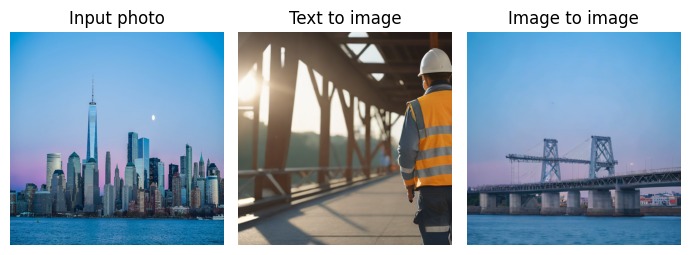

In [6]:
#@title Python Code - Image Generation Workflows

# This example shows simple image generation workflows.
# It uses compact Hugging Face diffusion pipelines.
# The prompts reflect civil engineering inspection scenes.

# !pip install -q diffusers accelerate safetensors transformers

import time
import urllib.request

import torch
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from diffusers import AutoPipelineForText2Image
from diffusers import AutoPipelineForImage2Image

# Set deterministic seeds for repeatable outputs.
seed_value = 7
np.random.seed(seed_value)

torch.manual_seed(seed_value)

# Choose GPU when available for speed.
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Device:", device, "Torch:", torch.__version__)
if device == "cpu":
    print("Note: CPU inference may be slow.")

# Download one realistic bridge photo.
image_url = "https://images.unsplash.com/photo-1514565131-fce0801e5785?auto=format&fit=crop&w=768&q=80"
urllib.request.urlretrieve(image_url, "bridge_photo.jpg")

# Load and resize the input image.
input_image = Image.open("bridge_photo.jpg").convert("RGB")
input_image = input_image.resize((512, 512))

print("Input image size:", input_image.size)

# Define a realistic text prompt.
text_prompt = (
    "photorealistic bridge inspection scene, civil engineer wearing safety vest, "

    "close view of steel members, realistic lighting, documentary photo")

# Load a fast text to image pipeline.
load_kwargs = {"torch_dtype": dtype}
if device == "cuda":

    load_kwargs["variant"] = "fp16"

t2i_pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo", **load_kwargs)
t2i_pipe = t2i_pipe.to(device)

t2i_pipe.set_progress_bar_config(disable=True)

# Generate one text to image result.
start_t2i = time.time()
gen_t2i = torch.Generator(device=device).manual_seed(seed_value)

text_image = t2i_pipe(
    prompt=text_prompt,
    num_inference_steps=2,

    guidance_scale=0.0,
    height=512,
    width=512,

    generator=gen_t2i
).images[0]

t2i_time = time.time() - start_t2i
print("Text prompt:", text_prompt[:70] + "...")

# Build an image to image pipeline.
i2i_pipe = AutoPipelineForImage2Image.from_pipe(t2i_pipe)
i2i_pipe = i2i_pipe.to(device)

i2i_pipe.set_progress_bar_config(disable=True)

# Define a gentle realistic transformation.
i2i_prompt = (
    "photorealistic bridge inspection photo, slightly overcast sky, "

    "clearer structural details, realistic concrete and steel textures")

# Generate one image to image result.
# Keep num_inference_steps * strength >= 1.
start_i2i = time.time()

gen_i2i = torch.Generator(device=device).manual_seed(seed_value + 1)

image_image = i2i_pipe(
    prompt=i2i_prompt,
    image=input_image,

    strength=0.5,
    num_inference_steps=2,
    guidance_scale=0.0,

    generator=gen_i2i
).images[0]

i2i_time = time.time() - start_i2i
print("Text-to-image seconds:", round(t2i_time, 2))
print("Image-to-image seconds:", round(i2i_time, 2))

# Show compact side by side results.
fig, axes = plt.subplots(1, 3, figsize=(7, 3))
axes[0].imshow(input_image)

axes[0].set_title("Input photo")
axes[0].axis("off")

axes[1].imshow(text_image)
axes[1].set_title("Text to image")
axes[1].axis("off")

axes[2].imshow(image_image)
axes[2].set_title("Image to image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## **3. Hugging Face Multimodal Tasks**

### **3.1. Text to Video**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_03_01.jpg?v=1776979248" width="250">



>* Text prompts generate new videos over time.
>* Models synthesize motion, not retrieve clips.

>* Text to video adds time-based output complexity.
>* Models map language into consistent visual sequences.

>* Text prompts create rough visual scenarios.
>* Simple interfaces reveal multimodal input-output patterns.



Prompt summary:
           item                                                                                                  value
           task                                                                                          text to video
          model                                                                       damo-vilab/text-to-video-ms-1.7b
         prompt Drone view of a highway bridge inspection, realistic daylight, slow camera motion, cinematic, detailed
         frames                                                                                                     16
           size                                                                                                256x256
            fps                                                                                                      8
inference steps                                                                                                     25
Torch version: 2.11.0
Device: cp

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 
/Users/mrpro/venvs/course_dev_ops/lib/python3.12/site-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `TextToVideoSDPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


Saved video metadata:
  field                    value
   file bridge_text_to_video.mp4
 frames                       16
    fps                        8
  width                      256
 height                      256
  bytes                    73976
seconds                    84.12


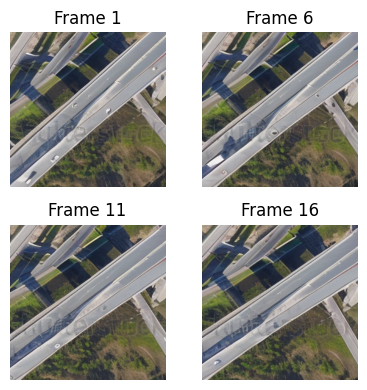

Storyboard saved: bridge_storyboard.png
Video saved: bridge_text_to_video.mp4


In [7]:
#@title Python Code - Text to Video

# This lesson shows text to video basics.
# We use a beginner friendly Hugging Face Diffusers workflow.
# A civil prompt becomes a short generated video clip.

# pip install diffusers transformers accelerate imageio imageio-ffmpeg moviepy

import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler
from diffusers.utils import export_to_video
from IPython.display import Video, display

# Set small deterministic seeds.
random.seed(7)
np.random.seed(7)

torch.manual_seed(7)

# Choose a simple civil prompt.
prompt = (
    "Drone view of a highway bridge inspection, "

    "realistic daylight, slow camera motion, cinematic, detailed")

# Store small output settings.
frame_count = 16
height = 256

width = 256
fps = 8
num_inference_steps = 25

# Select the text to video model.
model_id = "damo-vilab/text-to-video-ms-1.7b"

# Prepare output file names.
video_path = "bridge_text_to_video.mp4"
story_path = "bridge_storyboard.png"

# Build a prompt summary table.
summary = pd.DataFrame({
    "item": [

        "task",
        "model",
        "prompt",

        "frames",
        "size",
        "fps",

        "inference steps"],
    "value": [
        "text to video",

        model_id,
        prompt,
        frame_count,

        str(width) + "x" + str(height),
        fps,
        num_inference_steps],})

# Print a compact summary.
print("Prompt summary:")
print(summary.to_string(index=False))

print("Torch version:", torch.__version__)

# Detect hardware safely.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Track generation time.
start_time = time.time()

# Load the text to video pipeline.
pipe = DiffusionPipeline.from_pretrained(
    model_id,

    torch_dtype=torch.float16,
    variant="fp16",)

# Use a faster scheduler.
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config)

# Save VRAM on free Colab GPUs.
pipe.enable_model_cpu_offload()
pipe.enable_vae_slicing()

# Reduce progress bar noise.
pipe.set_progress_bar_config(disable=True)

# Generate video frames from the text prompt.
result = pipe(
    prompt,

    num_inference_steps=num_inference_steps,
    num_frames=frame_count,
    height=height,

    width=width,)

# Collect the generated frames.
frames = result.frames[0]

# Validate frame collection.
if len(frames) != frame_count:
    raise ValueError("Unexpected frame count.")

# Save the short video clip.
video_path = export_to_video(
    frames,

    output_video_path=video_path,
    fps=fps,)

# Calculate generation time.
elapsed_seconds = round(time.time() - start_time, 2)

# Build simple metadata.
file_size = os.path.getsize(video_path)
metadata = pd.DataFrame({

    "field": [
        "file",
        "frames",

        "fps",
        "width",
        "height",

        "bytes",
        "seconds"],
    "value": [

        video_path,
        len(frames),
        fps,

        width,
        height,
        file_size,

        elapsed_seconds],})

# Print compact metadata.
print("Saved video metadata:")
print(metadata.to_string(index=False))

# Plot a small storyboard figure.
fig, axes = plt.subplots(2, 2, figsize=(4, 4))

# Select four evenly spaced storyboard frames.
show_ids = np.linspace(
    0,

    len(frames) - 1,
    4,
    dtype=int)

# Display selected frames.
for ax, idx in zip(axes.ravel(), show_ids):
    ax.imshow(frames[idx])

    ax.set_title("Frame " + str(idx + 1))
    ax.axis("off")

# Save and show the storyboard.
plt.tight_layout()
plt.savefig(story_path, dpi=120)

plt.show()

# Display the generated video inside the notebook.
display(Video(video_path, embed=True))

print("Storyboard saved:", story_path)
print("Video saved:", video_path)

### **3.2. Flexible Multimodal Interfaces**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_03_02.jpg?v=1776979288" width="250">



>* Accepts varied inputs and outputs flexibly
>* Links engineering media through input-output transformations

>* Multimodal interfaces translate between different media.
>* One workflow handles many input-output combinations.

>* General workflows enable cross-modal AI experimentation
>* Fluid formats mirror real engineering communication



### **3.3. Cross Modal Interfaces**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_A/image_03_03.jpg?v=1776979327" width="250">



>* Cross modal tasks translate meaning across media.
>* Useful for engineering communication and review.

>* Cross modal tasks change input and output.
>* Python pipelines stay similar across modalities.

>* Cross modal tools improve access and teamwork.
>* Track input, output, and conversion purpose.



# <font color="#418FDE" size="6.5" uppercase>**Introductory NLP Libraries and Hugging Face Workflows**</font>


In this lecture, you learned to:
- Use spaCy and NLTK to preprocess and analyze simple text data relevant to civil engineering workflows. 
- Apply beginner-friendly Hugging Face workflows for introductory text, image, audio, and video generation tasks. 
- Describe the basic input-output patterns of single-modal and multi-modal AI tasks using simple Python examples. 

In the next Lecture (Lecture B), we will go over 'APIs and Simple Civil Engineering AI Workflows'